In [144]:
%pip install emoji

In [145]:
import pandas as pd
import numpy as np
from spacy.tokenizer import Tokenizer
from spacy.lang.en import English
import emoji
import spacy
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import re
from collections import Counter

Load the Dataset

In [146]:
data=pd.read_csv('IMDB Dataset.csv')
data

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


Exploratory Data Analysis

In [147]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [148]:
print(f"Duplicates: {data.duplicated().sum()}")

Duplicates: 418


In [149]:
data.drop_duplicates(inplace=True)
data.reset_index(drop=True, inplace=True)

In [150]:
data.shape

(49582, 2)

In [151]:
data.sentiment.value_counts()

,count
sentiment,
positive,24884
negative,24698


Converting positive to 0 and negative to 1 using factorize method in pandas

In [152]:
data['sentiment'] = data['sentiment'].map({'positive': 0, 'negative': 1})

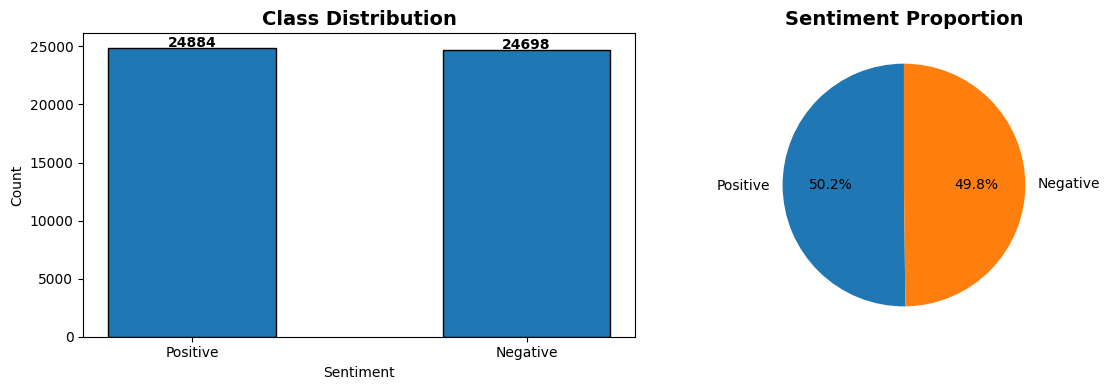


Class Counts:
Positive Reviews :24884
Negative Reviews :24698


In [153]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

label_map = {0: 'Positive', 1: 'Negative'}
readable_labels = [label_map[i] for i in counts.index]

# Count plot
counts = data['sentiment'].value_counts()
axes[0].bar(readable_labels, counts.values, edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=readable_labels, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Sentiment Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nClass Counts:")
print(f'Positive Reviews :{counts[0]}')
print(f'Negative Reviews :{counts[1]}')

Pre processing on the data

In [154]:
def clean_text(text):
    text = emoji.demojize(text, delimiters=(" ", " "))
    # Note: I removed your manual punctuation spacing!
    # spaCy's pre-trained model handles punctuation perfectly on its own.
    # We just need to clean up extra HTML tags and white spaces.
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    return ' '.join(text.split())

In [155]:
data['clean_review'] = data['review'].apply(clean_text)

Tokenisation & Lemmetisation

In [156]:
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

all_lemmatized_reviews = []

# nlp.pipe processes the 50,000 reviews in hyper-fast batches
for doc in nlp.pipe(data['clean_review'], batch_size=1000):

    # Extract the lemma for each word.
    # Optional bonus: We filter out punctuation and spaces to make your data even cleaner!
    lemmas = [token.lemma_.lower() for token in doc if not token.is_punct and not token.is_space]

    # Save the list of lemmas
    all_lemmatized_reviews.append(lemmas)

# 4. Save the final results back to the dataframe
data['lemmatized_tokens'] = all_lemmatized_reviews


Removing Stop Words

In [157]:
# 1. Load the default set of stop words
# Note: We use .copy() so we don't accidentally permanently change spaCy's default library on your computer!
stop_words = spacy.lang.en.stop_words.STOP_WORDS.copy()

# 2. Words that are CRUCIAL for sentiment that we want to KEEP in our data
exceptions = ['not', 'no', 'cannot', 'neither', 'never', 'but', 'however', 'although', 'though', 'except', 'yet', 'against', 'very', 'too', 'really', 'almost', 'least', 'less', 'more', 'most', 'always']

# 3. Remove our exceptions from the stop_word list
for word in exceptions:
    stop_words.discard(word) # .discard() safely removes it from the set

# --- Now run your function using this safe, updated list ---
def remove_stop_words(token_list):
    filtered_words = [word for word in token_list if word.lower() not in stop_words]
    return ' '.join(filtered_words)


In [158]:
data['no_stops'] = data['lemmatized_tokens'].apply(remove_stop_words)
data['final_text_for_model'] = data['no_stops']

Train Test Split

In [159]:
# Define our Features (X) and our Target (y)
X = data['final_text_for_model']
y = data['sentiment']

# Perform the Train/Test Split
# We hold back 20% of the data strictly for testing (test_size=0.2)
# random_state=42 ensures we get the same random split every time we run this code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data size: {len(X_train)} reviews")
print(f"Testing data size: {len(X_test)} reviews")

Training data size: 39665 reviews
Testing data size: 9917 reviews


Vectorization

In [160]:
# Cell 2: Initialize and fit the Vectorizer
# max_features=10000 tells it to only keep the top 10,000 most important words to save memory
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

# We fit (learn the vocabulary) AND transform (convert to numbers) the training data
X_train_vectorized = vectorizer.fit_transform(X_train)

# We ONLY transform the testing data (it must be evaluated on the vocabulary learned from the training set)
X_test_vectorized = vectorizer.transform(X_test)

Model Traning

In [161]:
# from sklearn.linear_model import LogisticRegression

# # 1. Initialize the model
# # max_iter=1000 ensures the math has enough time to fully converge
# model = LogisticRegression(max_iter=1000)

# # 2. Train the model! (This is where the actual "learning" happens)
# print("Training the model...")
# model.fit(X_train_vectorized, y_train)
# print("Training complete!")



from sklearn.svm import LinearSVC

# 1. Initialize the model
model = LinearSVC(max_iter=2000)

# 2. Train the model
print("Training the model...")
model.fit(X_train_vectorized, y_train)
print("Training complete!")

Training the model...
Training complete!


              precision    recall  f1-score   support

    Positive       0.88      0.90      0.89      4978
    Negative       0.89      0.88      0.89      4939

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



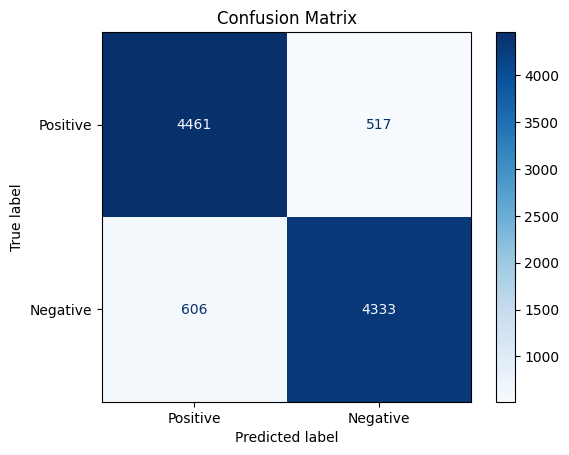

In [162]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Predict on the test set
y_pred = model.predict(X_test_vectorized)

# Full metrics report
print(classification_report(y_test, y_pred, target_names=['Positive', 'Negative']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Positive', 'Negative'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

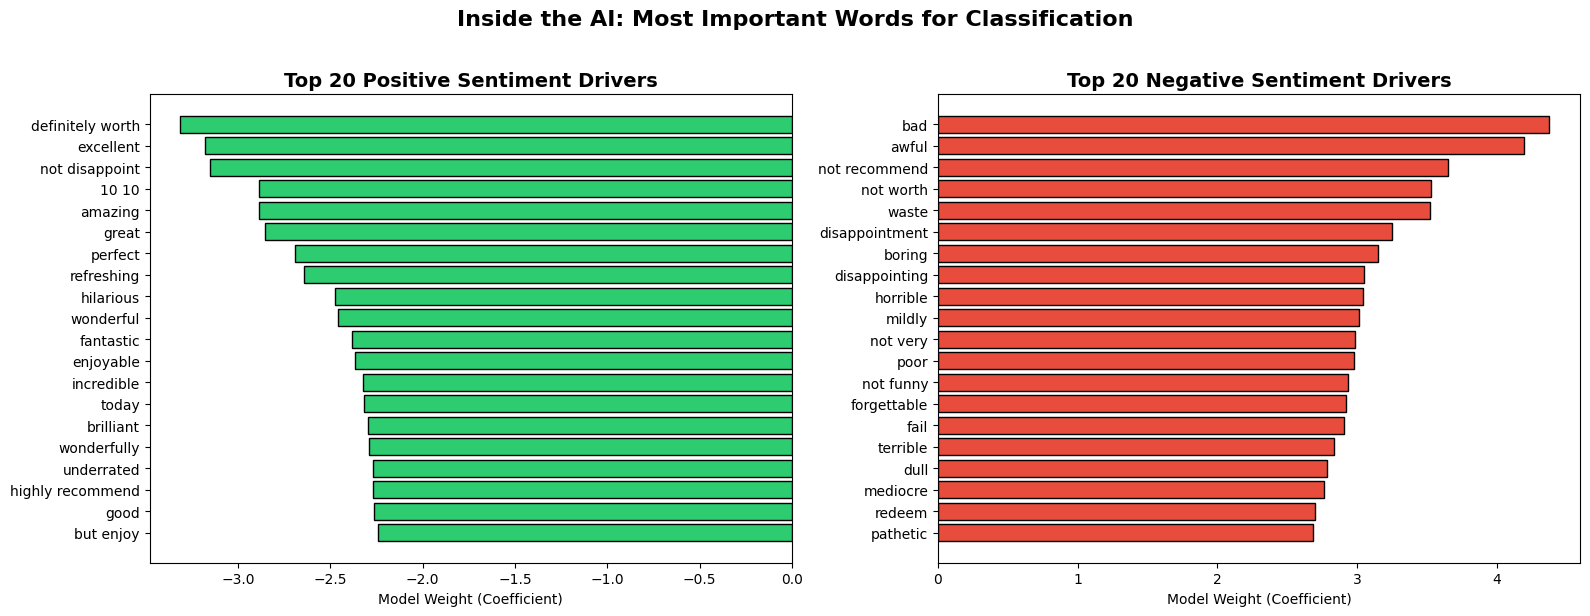

In [163]:

feature_names = vectorizer.get_feature_names_out()
coefs = model.coef_[0]

top_n = 20
top_neg_idx = coefs.argsort()[-top_n:][::-1]  # Negative drivers (highest weights)
top_pos_idx = coefs.argsort()[:top_n]          # Positive drivers (lowest weights)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(feature_names[top_pos_idx][::-1], coefs[top_pos_idx][::-1], color='#2ecc71', edgecolor='black')
axes[0].set_title('Top 20 Positive Sentiment Drivers', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Model Weight (Coefficient)')

axes[1].barh(feature_names[top_neg_idx][::-1], coefs[top_neg_idx][::-1], color='#e74c3c', edgecolor='black')
axes[1].set_title('Top 20 Negative Sentiment Drivers', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Model Weight (Coefficient)')

plt.suptitle('Inside the AI: Most Important Words for Classification', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [164]:
# 1. Create a function that handles the entire pipeline
def predict_my_review(my_text):
    print(f"Original Review: '{my_text}'")

    # Step A: Clean the text (using your advanced regex cleaner)
    clean = clean_text(my_text)

    # Step B: Tokenize and Lemmatize using spaCy
    doc = nlp(clean)
    lemmas = [token.lemma_.lower() for token in doc if not token.is_punct and not token.is_space]

    # Step C: Remove stop words (using your custom IMDB list)
    final_string = remove_stop_words(lemmas)

    # Step D: Vectorize
    # VERY IMPORTANT: Use .transform(), NOT .fit_transform()!
    # The model must use the vocabulary it ALREADY learned.
    vectorized_text = vectorizer.transform([final_string])

    # Step E: Predict the sentiment
    prediction = model.predict(vectorized_text)

    # Step F: Output the result
    # Remember: 0 was mapped to Positive, 1 was mapped to Negative in your factorize step
    if prediction[0] == 0:
        print("Prediction: POSITIVE 😊\n" + "-"*40)
    else:
        print("Prediction: NEGATIVE 😡\n" + "-"*40)

# 2. Test it out!
predict_my_review("the movie was not great")
predict_my_review("What a waste of time. The acting was terrible and the plot made no sense.")
predict_my_review("The special effects were okay, but overall it was not good.")
predict_my_review("I thought it would be bad, but it was actually incredible!")

Original Review: 'the movie was not great'
Prediction: POSITIVE 😊
----------------------------------------
Original Review: 'What a waste of time. The acting was terrible and the plot made no sense.'
Prediction: NEGATIVE 😡
----------------------------------------
Original Review: 'The special effects were okay, but overall it was not good.'
Prediction: NEGATIVE 😡
----------------------------------------
Original Review: 'I thought it would be bad, but it was actually incredible!'
Prediction: NEGATIVE 😡
----------------------------------------
